In [313]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import numpy as np
from scipy.optimize import curve_fit
from glob import glob
from scipy.signal import savgol_filter
import seaborn as sns
from pathlib import Path 
import re
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In this notebook, you will work on the plate reader growth data of different  𝑆.𝑐𝑒𝑟𝑒𝑣𝑖𝑠𝑖𝑎𝑒 strains containing various combinations of the GAL1 and DOA1 promoter with either the GAL1 or DOA1 gene + mScarlet fluorophore exposed to different carbon source transitions.

Firstly, we want to focus on how the strain alterations affect the growth in each strain, especially compared to the wildtype strain. Some of the strains used are detailed in **panel A** of **Figure 1** below. 

The strains which are not depicted are: 

- YET784 = P<sub>Gal1</sub> - DOA1
- YET963 = P<sub>Doa1</sub> - mScarlet
  
All strains and their descriptions can be found in "Yeast strains.pdf"

- For these 2 missing strains that are not depicted, do you have a clear idea of their strains characteristics?
YET784 places DOA1 downstream of the Gal1 promoter. This should lead to expression DOA1 when galactose is present, possibly leading to some physiological change in the cell. 

YET963 constitutes the deletion of DOA1, a gene which plays a role in protein degradation, stress response and mediates response to DNA damage by shuttling ubiquitin away from proteome and into chromatin-modification?

Expectation is that its removal leads to cell death as it plays an important role.
Secondly, we want to focus how the different carbon source transitions affect growth in every strain. The growth protocol is detailed in the word document found in this folder titled "Plate Reader Exp Set Up.pdf" and is summarized in the schematic shown below in **panel B**. The different transitions are:

'GLUGLU', 'GALGAL', 'RAFRAF', 'GLUGAL', 'GLURAF', 'RAFGAL', 'GALGLU', 'RAFGLU', 'GALRAF'. 

- Do you already have certain expectations of which transitions are faster or slower growers?

![title](imgs/SC_practical_growth_reader_schematic.png)

***

# Load and format data.

In [386]:
#Parse the data files
files = glob(fr'Plate Reader Data/*.xlsx')
files.sort()
files

['Plate Reader Data/YET784_DATA_1312.xlsx',
 'Plate Reader Data/YET858_DATA_2305.xlsx',
 'Plate Reader Data/YET911_DATA_2401.xlsx',
 'Plate Reader Data/YET937_DATA_2401.xlsx',
 'Plate Reader Data/YET938_DATA_2701.xlsx',
 'Plate Reader Data/YET962_DATA_2901.xlsx',
 'Plate Reader Data/YET963_DATA_2901.xlsx']

In [387]:
# Load different files as a pandas dataframe using the index
curfile = files[-2]
strain = curfile.split("/")[1].split("_")[0]
df = pd.read_excel(curfile, sheet_name="Table All Cycles")

# Display the first few rows of the DataFrame
df.head(15) 

,User: USER,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49
0,Path: C:\Program Files (x86)\BMG\SPECTROstar N...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Test ID: 376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Test Name: MO_OD600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Date: 29/01/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Time: 13:00:54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ID1: MO_OD600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ID2: Absorbance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"ID3: 29/01/2025,13:00:54",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Absorbance,NaN,NaN,Absorbance values are displayed as OD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- What do you notice about the first 15 rows of the dataframe? It seems that there is some metadata that should not be included. Are you able to remove it? The resulting dataframe should only contain the raw data columns A1-F8 and the time column.

In [422]:
# your code here: 
#initialise df_cleaned
# 1. Set the column headers based on the 12th row of the dataframe (index 11)
df_cleaned = df.copy()
df_cleaned.columns = df.iloc[11]

# 2. Remove the first 12 rows
df_cleaned = df_cleaned.iloc[13:].reset_index(drop=True)

# 3. Reset the index after dropping rows (otherwise the indexing of the dataframe will be off)

# 4. Drop the first column named Well*
df_cleaned = df_cleaned.drop(columns=['Well'])

# 5. Rename the new first column to 'Time'
df_cleaned = df_cleaned.rename(columns={df_cleaned.columns[0]: 'Time'})
df_cleaned.head(15)



11,Time,A1,A2,A3,A4,A5,A6,A7,A8,B1,...,E7,E8,F1,F2,F3,F4,F5,F6,F7,F8
0,0 h,0.081,0.08,0.078,0.085,0.086,0.078,0.082,0.08,0.098,...,0.091,0.091,0.075,0.078,0.077,0.084,0.084,0.077,0.08,0.076
1,0 h 10 min,0.084,0.082,0.081,0.085,0.086,0.08,0.083,0.08,0.092,...,0.091,0.09,0.075,0.08,0.079,0.087,0.083,0.08,0.081,0.078
2,0 h 20 min,0.082,0.082,0.081,0.084,0.085,0.08,0.085,0.08,0.096,...,0.093,0.092,0.075,0.081,0.079,0.086,0.083,0.081,0.083,0.079
3,0 h 30 min,0.081,0.082,0.081,0.084,0.086,0.079,0.083,0.078,0.091,...,0.09,0.091,0.081,0.08,0.079,0.085,0.08,0.078,0.082,0.079
4,0 h 40 min,0.082,0.082,0.081,0.084,0.087,0.08,0.084,0.078,0.093,...,0.092,0.093,0.095,0.081,0.079,0.086,0.083,0.079,0.083,0.079
5,0 h 50 min,0.083,0.082,0.081,0.084,0.085,0.081,0.084,0.078,0.093,...,0.092,0.092,0.077,0.082,0.079,0.086,0.083,0.079,0.082,0.078
6,1 h,0.082,0.082,0.08,0.084,0.084,0.08,0.083,0.078,0.093,...,0.092,0.093,0.157,0.081,0.079,0.085,0.083,0.079,0.081,0.078
7,1 h 10 min,0.083,0.083,0.081,0.085,0.086,0.081,0.084,0.079,0.092,...,0.095,0.094,0.076,0.081,0.079,0.085,0.082,0.08,0.082,0.077
8,1 h 20 min,0.084,0.082,0.079,0.082,0.085,0.08,0.083,0.077,0.091,...,0.094,0.095,0.104,0.08,0.078,0.085,0.081,0.079,0.081,0.078
9,1 h 30 min,0.082,0.082,0.08,0.084,0.084,0.08,0.083,0.079,0.093,...,0.095,0.096,0.076,0.081,0.079,0.086,0.082,0.081,0.11,0.078


The time columns is in a strange format too. Can you convert the data to hours and minutes in the column onto two new columns named "time_hours" and "time_minutes"?

In [424]:
#Your code here:  

df_cleaned[["time_hours", "time_minutes"]] = df_cleaned.Time.str.split(' h ', expand=True)
df_cleaned["time_minutes"] = df_cleaned["time_minutes"].str.replace(" min", "")
df_cleaned["time_minutes"] = pd.to_numeric(df_cleaned["time_minutes"])
df_cleaned["time_hours"] = pd.to_numeric(df_cleaned["time_hours"])
df_cleaned = df_cleaned.drop("Time", axis=1)

Next, we will start naming the different columns according to the conditions they belong to. Below you can find the plate layout.

![title](imgs/Plate_layout.png)

- Can you fill in the dictionary beneath to map the columns to each condition, ignoring the blanks?

In [412]:
# Map of conditions
#These conditions are valid for the data coming from SPECTROSTAR YZMA; the following list matches the automatic columns 
#name given by the machine to each nutrient transition tested
conditions = {
    'GLUGLU': ['E1', 'E2', 'E7', 'E8'],'GLUGAL': ["B1", "B2", "B7", "B8"], 
    'GALGLU': ['B3','B4','B5',"B6"],'GALGAL': ['A4',"A5","E3","E6"],
    'GLURAF':['C1','C2','C7','C8'],'RAFGLU':['C3','C4','C5','C6'],
    'RAFGAL':['D1','D2','D7','D8'],'GALRAF':['D3','D4','D5','D6'],
    'RAFRAF':['E4','F4','E5','F5']
# fill in the rest
} 

In [413]:
all_samples = sum(conditions.values(), [])

rename_dict = {}
for condition, samples in conditions.items():
    rename_dict.update({
        samples[0]: f"{condition}1",
        samples[1]: f"{condition}1",
        samples[2]: f"{condition}2",
        samples[3]: f"{condition}2"
    })

# Rename the columns in the DataFrame
df_renamed = df_cleaned.rename(columns=rename_dict)

# Display the DataFrame with the new column names
df_renamed.head(3)

11,A1,A2,A3,GALGAL1,GALGAL1,A6,A7,A8,GLUGAL1,GLUGAL1,...,F1,F2,F3,RAFRAF1,RAFRAF2,F6,F7,F8,time_hours,time_minutes
0,0.081,0.08,0.078,0.085,0.086,0.078,0.082,0.08,0.098,0.095,...,0.075,0.078,0.077,0.084,0.084,0.077,0.08,0.076,NaN,NaN
1,0.084,0.082,0.081,0.085,0.086,0.08,0.083,0.08,0.092,0.092,...,0.075,0.08,0.079,0.087,0.083,0.08,0.081,0.078,0.166667,10.0
2,0.082,0.082,0.081,0.084,0.085,0.08,0.085,0.08,0.096,0.093,...,0.075,0.081,0.079,0.086,0.083,0.081,0.083,0.079,0.333333,20.0


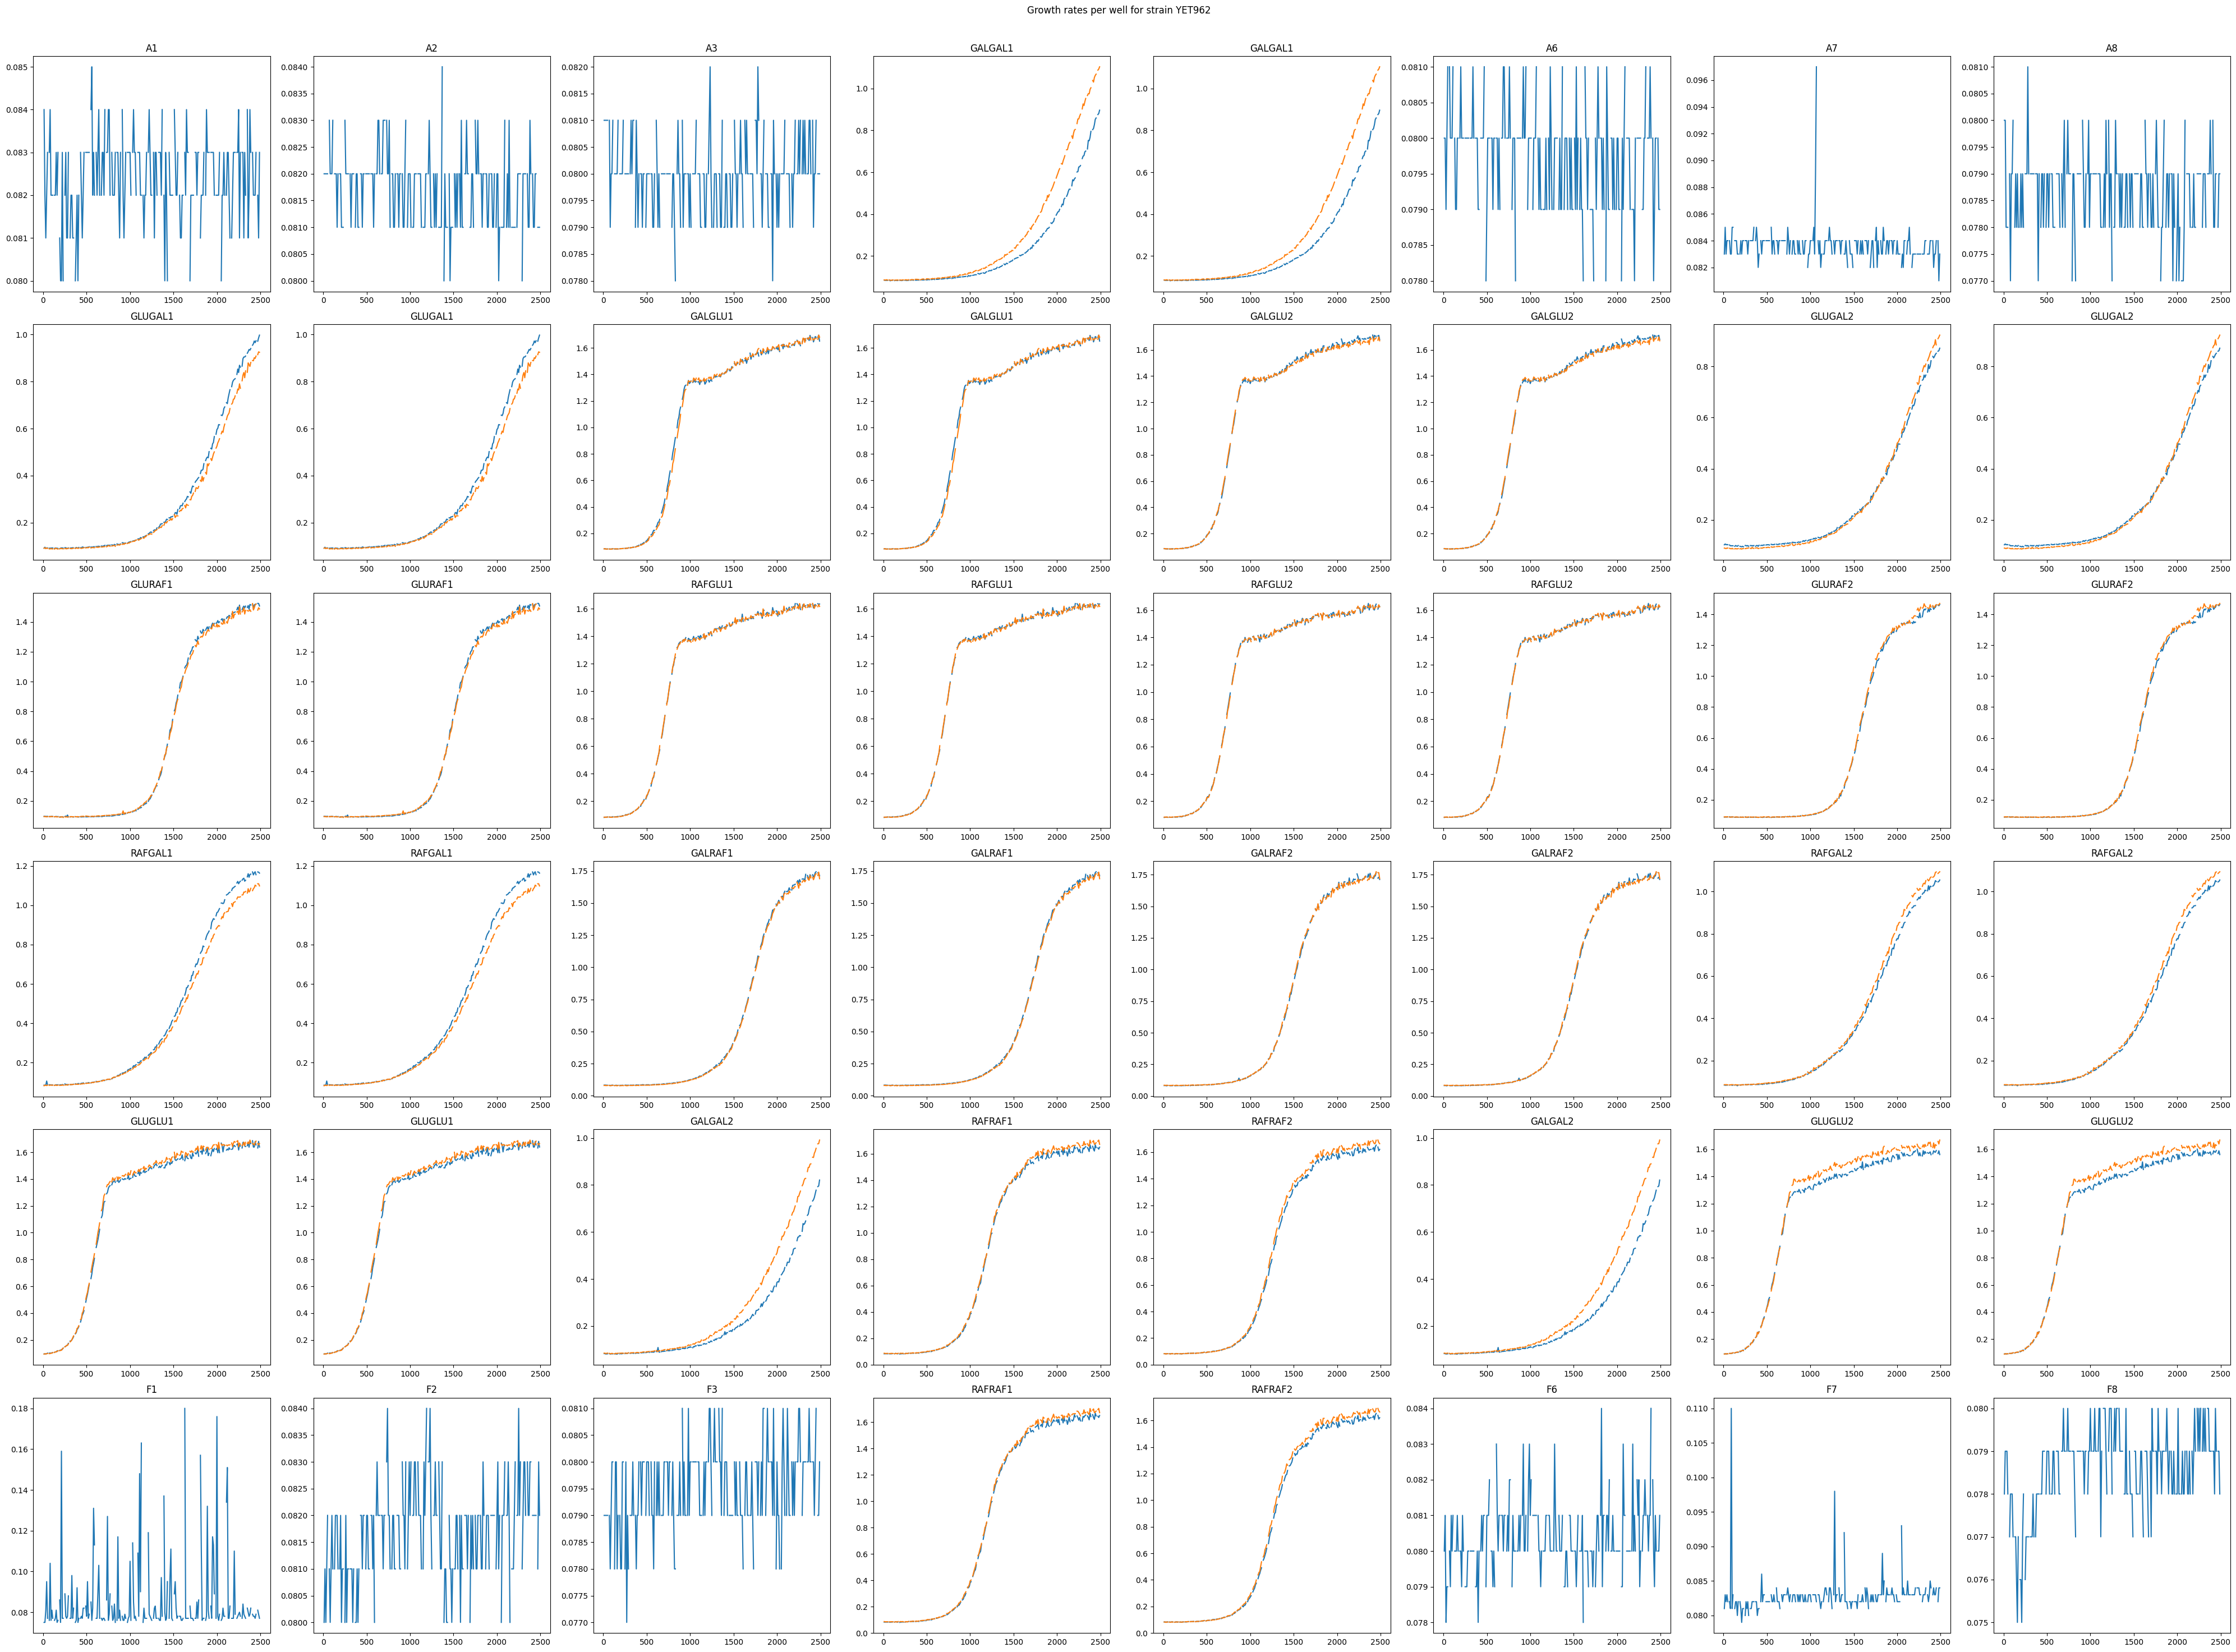

In [ ]:
# Create a figure and set the number of subplots (48 subplots, arranged in 6 rows and 8 columns)
num_rows = 6
num_cols = 8
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5))  #6x8 grid of subplots

# Flatten the 2D axes array to 1D for easy indexing
axes = axes.flatten()

# Collect the variable names of the renamed columns, skipping 'time','time_delta','time_in_hours' and 'time_in_minutes'
# or any column contianing something different than raw OD600 values
renamed_columns = [col for col in df_renamed.columns if col not in ['time','time_delta','time_minutes','time_hours']]

# iterate over the renamed columns and plot them below
#### YOUR CODE HERE for iterating over the columns and plotting them in the 48 different subplots ###########################
for i in range(len(renamed_columns)):
    axes[i].plot(df_renamed[renamed_columns[i]])
    axes[i].set_title(renamed_columns[i])


#### END CODE BLOCK #########################################################################################################

# Set the overall title of the figure
# fig.suptitle('RAW DATA PLOT', fontsize=16) 

# # Adjust layout to prevent overlap
plt.tight_layout() 
plt.subplots_adjust(top=0.95)   # Adjust the space for the suptitle 
plt.suptitle("Growth rates per well for strain " + strain)
plt.show()  # Display the plots 
fig.savefig(f"Results/growth rate wells {strain}.png", dpi=300)


- Look at the graph above and compare it to the plate layout. Are the global results meeting your expectations?
yep

***

# Calculating the growth rate and the lag phase and plotting.

![title](imgs/Growth_curve_characteristics.png)

Now that you have seen the growth data we want to extract some important features from it, being the lag phase and the maximal growth rate. The maximal growth rate is determined by fitting a linear curve to the exponential part of the logged transformed growth data. After, we can determine the lag phase by finding where this fitted linear curve and the population size at timepoint zero intersect (see panel 3).

However, before we can fit a linear curve to the exponential part of the growth data, we first have to:

log transform our growth data, and remove noise in our data by using a smoothing function (panel 1).
Find the section of the graph where a linear curve should be fitted to i.e. the linear part of log transformed growth data (panel 2). In the code below we will perform these operations.

In [415]:
#mean calculation and log transformation 
conditions_samples = {
    'GLUGLU': ['GLUGLU1', 'GLUGLU1', 'GLUGLU2', 'GLUGLU2'],
    'GALGAL': ['GALGAL1', 'GALGAL1', 'GALGAL2', 'GALGAL2'],
    'RAFRAF': ['RAFRAF1', 'RAFRAF1', 'RAFRAF2', 'RAFRAF2'],
    'GLUGAL': ['GLUGAL1', 'GLUGAL1', 'GLUGAL2', 'GLUGAL2'],
    'GLURAF': ['GLURAF1', 'GLURAF1', 'GLURAF2', 'GLURAF2'],
    'RAFGAL': ['RAFGAL1', 'RAFGAL1', 'RAFGAL2', 'RAFGAL2'],
    'GALGLU': ['GALGLU1', 'GALGLU1', 'GALGLU2', 'GALGLU2'],
    'RAFGLU': ['RAFGLU1', 'RAFGLU1', 'RAFGLU2', 'RAFGLU2'],
    'GALRAF': ['GALRAF1', 'GALRAF1', 'GALRAF2', 'GALRAF2']
}

# Initialize the df_transformed DataFrame to store log-transformed means
df_transformed = pd.DataFrame()

# Calculate the means for each condition within a sample
for condition, samples in conditions_samples.items():
    # Extract corresponding sample columns for the condition from df_final
    sample1, sample2, sample3, sample4 = samples
    sample_data = df_renamed[['time_hours', sample1, sample2, sample3, sample4]]
    
    # Ensure all columns are numeric and handle missing values (NaN)
    sample_data = sample_data.apply(pd.to_numeric, errors='coerce')
    
    # Calculate the mean of Sample1 and Sample2 for each condition, and Sample3 and Sample4 (2 technical replicates per biological replicate)
    sample_data['mean_sample1_sample2'] = sample_data[[sample1, sample2]].mean(axis=1)
    sample_data['mean_sample3_sample4'] = sample_data[[sample3, sample4]].mean(axis=1)
    
    # Log-transform the means (natural log)
    sample_data['log_mean_sample1_sample2'] = np.log(sample_data['mean_sample1_sample2'])
    sample_data['log_mean_sample3_sample4'] = np.log(sample_data['mean_sample3_sample4'])
    
    # Store the transformed means in df_transformed
    df_transformed[condition + '_log_sample1'] = sample_data['log_mean_sample1_sample2']
    df_transformed[condition + '_log_sample2'] = sample_data['log_mean_sample3_sample4'] 
    
df_transformed.head()  

,GLUGLU_log_sample1,GLUGLU_log_sample2,GALGAL_log_sample1,GALGAL_log_sample2,RAFRAF_log_sample1,RAFRAF_log_sample2,GLUGAL_log_sample1,GLUGAL_log_sample2,GLURAF_log_sample1,GLURAF_log_sample2,RAFGAL_log_sample1,RAFGAL_log_sample2,GALGLU_log_sample1,GALGLU_log_sample2,RAFGLU_log_sample1,RAFGLU_log_sample2,GALRAF_log_sample1,GALRAF_log_sample2
0,-2.327903,-2.396896,-2.459239,-2.476938,-2.488915,-2.488915,-2.338212,-2.307598,-2.327903,-2.391416,-2.447611,-2.459239,-2.494957,-2.459239,-2.465104,-2.494957,-2.513306,-2.494957
1,-2.359155,-2.402405,-2.459239,-2.476938,-2.465104,-2.488915,-2.385967,-2.338212,-2.348629,-2.424753,-2.471004,-2.465104,-2.488915,-2.459239,-2.501036,-2.501036,-2.507152,-2.482909
2,-2.343407,-2.380547,-2.471004,-2.482909,-2.465104,-2.488915,-2.359155,-2.327903,-2.343407,-2.413517,-2.453408,-2.465104,-2.476938,-2.465104,-2.488915,-2.482909,-2.501036,-2.476938
3,-2.353878,-2.402405,-2.465104,-2.494957,-2.476938,-2.513306,-2.402405,-2.348629,-2.359155,-2.424753,-2.459239,-2.471004,-2.507152,-2.476938,-2.501036,-2.501036,-2.513306,-2.494957
4,-2.333044,-2.380547,-2.459239,-2.488915,-2.465104,-2.488915,-2.375156,-2.333044,-2.359155,-2.413517,-2.348629,-2.459239,-2.507152,-2.482909,-2.482909,-2.476938,-2.513306,-2.488915


Next you will plot the log transformed data.

Text(0.5, 0.98, 'Log transformed growth data two samples strain YET962')

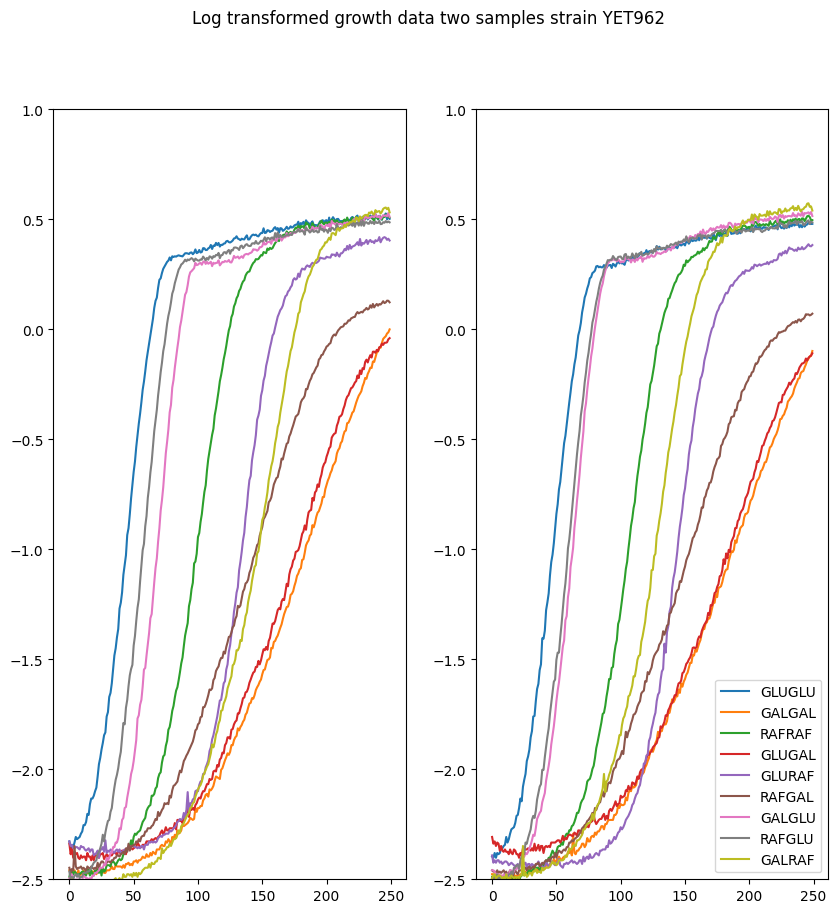

In [417]:
# Step 1: Add 'time_in_hours' from df_renamed to df_transformed 
df_transformed['time_hours'] = df_renamed['time_hours']

# Step 2: Plot all conditions for Sample1 and Sample2
# Sample 1 conditions: Collect all columns ending in '_log_sample1'
sample1_columns = df_transformed.loc[:, df_transformed.columns.str.endswith("_log_sample1")]
# Sample 2 conditions: Collect all columns ending in '_log_sample2'
sample2_columns = df_transformed.loc[:, df_transformed.columns.str.endswith("_log_sample2")]


# Plot setup. Initialise a plot containing two subplots: one for Sample1, one for Sample2:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,10))

# Step 3: Plot all Sample 1 conditions on the first subplot
for condition in sample1_columns:
    ax1.plot(sample1_columns[condition], label=condition.split('_', 1)[0])
ax1.set_ylim([-2.5,1])
# Set y-axis and x-axis limits for Sample 1 plot

# Step 4:  Plot all Sample 2 conditions on the second subplot
for condition in sample2_columns:
    ax2.plot(sample2_columns[condition], label=condition.split('_', 1)[0])
ax2.set_ylim([-2.5,1])
ax2.legend(loc="lower right")

# Set y-axis and x-axis limits for Sample 2 plot


# Set the overall title
fig.suptitle("Log transformed growth data two samples strain " + strain)

- How are the plots changed after log transformation?

Exponential growth turned linear wow.

- Why do we log transform the data?

Because a line fit to the log transformed data will have the growth rate as a slope

In [418]:
# save the plot
fig.savefig(f"Results/log growth rate {strain}.png", dpi=300)

Next we will apply a smoothing function to our logged transformed growth data.

for more information on the function parameters see: # added 

In [419]:
# SAVITZKY-GOLAY FILTER APPLICATION 
from scipy.signal import savgol_filter
#savgol_filter?

Text(0.5, 0.98, 'Smooth log transformed growth data two samples strain YET962')

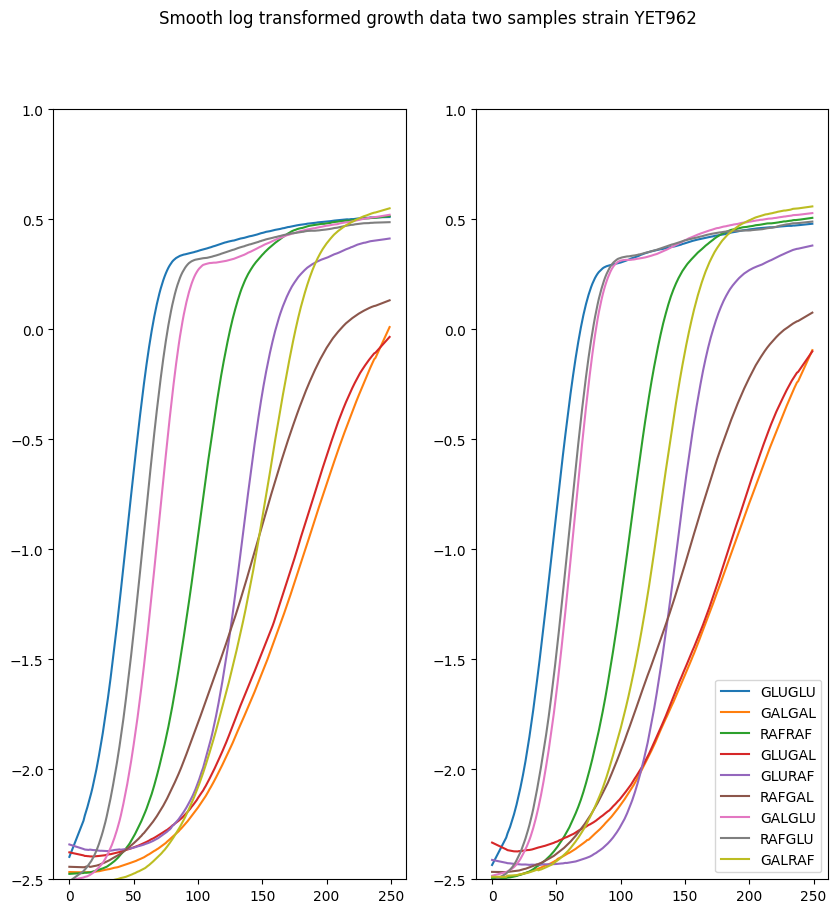

In [420]:
df_filtered = df_transformed.copy()  #create a copy to store filtered data

for col in df_transformed.columns:
    if col != "time_hours": 
        df_filtered[col] = savgol_filter(df_transformed[col], window_length=24, polyorder=1)

# Your code here plot the smoothed curves ######################################################### #

# Step 2: Plot all conditions for Sample1 and Sample2
# Sample 1 conditions: Collect all columns ending in '_log_sample1'
sample1_columns_filt = df_filtered.loc[:, df_filtered.columns.str.endswith("_log_sample1")]
# Sample 2 conditions: Collect all columns ending in '_log_sample2'
sample2_columns_filt = df_filtered.loc[:, df_filtered.columns.str.endswith("_log_sample2")]


# Plot setup. Initialise a plot containing two subplots: one for Sample1, one for Sample2:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,10))

# Step 3: Plot all Sample 1 conditions on the first subplot
for condition in sample1_columns_filt:
    ax1.plot(sample1_columns_filt[condition], label=condition.split('_', 1)[0])
ax1.set_ylim([-2.5,1])
# Set y-axis and x-axis limits for Sample 1 plot

# Step 4:  Plot all Sample 2 conditions on the second subplot
for condition in sample2_columns_filt:
    ax2.plot(sample2_columns_filt[condition], label=condition.split('_', 1)[0])
ax2.set_ylim([-2.5,1])
ax2.legend(loc="lower right")



# Set the overall title
fig.suptitle("Smooth log transformed growth data two samples strain " + strain)

In [326]:
fig.savefig(f"Results/smooth log growth rate {strain}.png", dpi=300)

- If the data was not smoothed, how could this affect the determination of the maximal growth rate?
It could be affected by noise

Now we will extract the maximal growth rates and the lagphase from each growth curve. We will need several functions to do this, which are all detailed below.

FUNCTIONS NEEDED FOR MAXIMAL GROWTH RATE AND LAG PHASE DETECTION 

In [327]:
# linear function to fit
def linear_func(x, mu, c):
    return mu * x + c
    
#to extract mu, tlag and save processed values into dataframes
def extract_mu_and_tlag(df, col_name):
    # Reset index for safety
    df = df.reset_index(drop=True) 

    # Compute the derivative of the data (growth rate)
    growth_rate = np.gradient(df[col_name])
    
    # Find index of maximum growth rate/
    max_growth_rate_index = np.nanargmax(growth_rate)
    growth_rate_max = np.nanmax(growth_rate)

    # Compute window size (ws) based on doubling time formula
    ws = round(np.log(2) / (growth_rate_max))
    if ws<3:
        ws = 3
        print(f'ws was calculated to be {ws}')

    # Ensure the indices are within bounds
    start_index = max(0, max_growth_rate_index - ws)
    end_index = min(len(df) - 1, max_growth_rate_index + ws)

    # Select window around max growth rate
    xdata = df.index[start_index:end_index + 1]  # Use index for cycles
    ydata = df[col_name].iloc[start_index:end_index + 1]  # Use column values for OD600
    
    # Fit a linear curve to the selected region
    try:
        popt, _ = curve_fit(linear_func, xdata, ydata)
        mu, c = popt  # Extract slope (mu) and intercept (c)
    except RuntimeError:
        mu, c = np.nan, np.nan  # Handle fitting failure

    # Calculate the mean population at Tzero over the first 3 datapoints
    t0 = df[col_name].iloc[:3].mean()  
    # Extraxt lagphase
    tlag = (t0 - c) / mu if mu != 0 else np.nan

    # List values fitted linear curve
    y=list(linear_func(df.index, mu,c))

    # Prepare output
    output_aggregate = {
        'max_growth_rate_index': [max_growth_rate_index],
        'start_index': [start_index],
        'end_index': [end_index],
        'ws': [ws] ,
        'mu': [mu * 6] ,
        'tlag': [tlag * 0.1666], #tlag in hours,
        'tzero': [t0],
        'c': [c],
    }
    output_raw_data = {
        'smoothed_values': df[col_name].values,
        'growth_rate': growth_rate * 6,
        'fitted_linear_curve': y, 
        'cycles': df.index.values,  # Store the index as 'cycles', every cycle is 10 mins
        'time_hours': df.time_hours
    }

    return pd.DataFrame(output_aggregate), pd.DataFrame(output_raw_data )

- Where in the code is written over which area the linear curve is fitted?
xdata =
ydata =

In [328]:
# APPLY THE FUNCTIONS TO THE DF_FILTERED DATAFRAME
results = []
results_raw = []

# List of columns to process (exclude 'time_in_hours')
columns_to_process = [col for col in df_filtered.columns if col != 'time_hours']

# Apply the function for each column
for col in columns_to_process:
    col_results, col_results_raw = extract_mu_and_tlag(df_filtered, col)
    col_results['column'] = col  # Store the column name for identification
    col_results_raw['column'] = col
    results.append(col_results)
    results_raw.append(col_results_raw)

# Combine all results into a single DataFrame
final_results = pd.concat(results).reset_index(drop=True)
final_results_raw = pd.concat(results_raw).reset_index(drop=True)

# Show the first few rows of the final results to inspect
final_results

# You can also have a look at the final_results raw table
#final_results_raw # what data is contained here

# Uncomment to save extracted data
final_results.to_csv(f'Results/final_results_{strain}.csv')

We can also visualize the extraction of lagphases and growth rates by plotting the values in the final results raw dataframe.

(-3.0, 0.8)

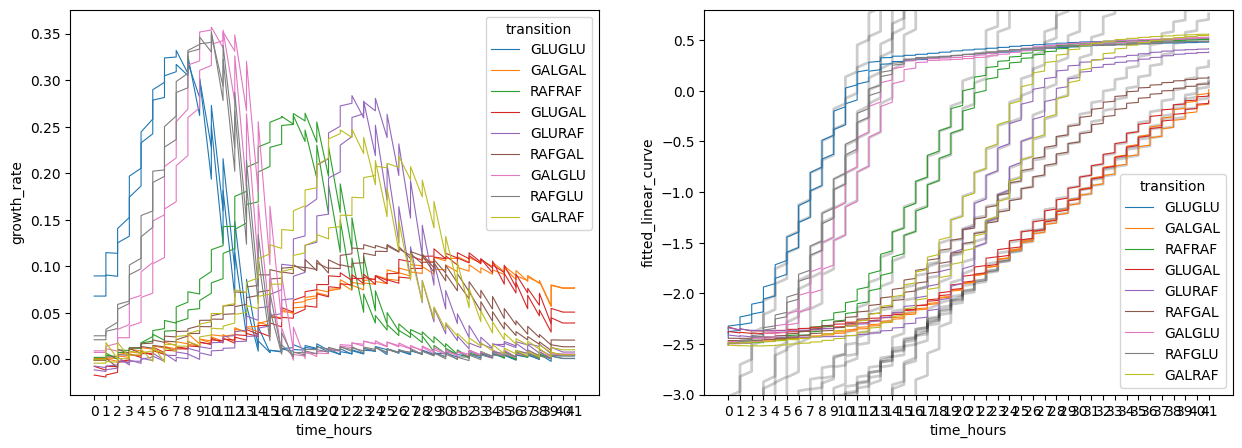

In [329]:
#add column as hue for seaborn
final_results_raw['transition'] = final_results_raw['column'].str.split('_',expand=True)[0]

fix,ax= plt.subplots(ncols=2, figsize=(15,5))

sns.lineplot(final_results_raw,y='growth_rate',x='time_hours', hue='transition', units='column',estimator=None,linewidth=.8,ax=ax[0])

sns.lineplot(final_results_raw,y='fitted_linear_curve',x='time_hours',color='black', units='column',estimator=None,linewidth=2,ax=ax[1],alpha=0.2)
sns.lineplot(final_results_raw,y='smoothed_values',x='time_hours', hue='transition', units='column',estimator=None,linewidth=.8,ax=ax[1])
ax[1].set_ylim(-3,.8)

- Go back to the function "extract_mu_and_tlag". Do you understand how the linear curve and the Tzero are used to determine the lagphase? 


***

- In the last part we extracted the growth rates and lagphase of the different strains. Now, we want to plot the differences in lag phases and growh rates. This part you will code yourself! Closely, inspect the plots you have created. What conclusions can be drawn? 

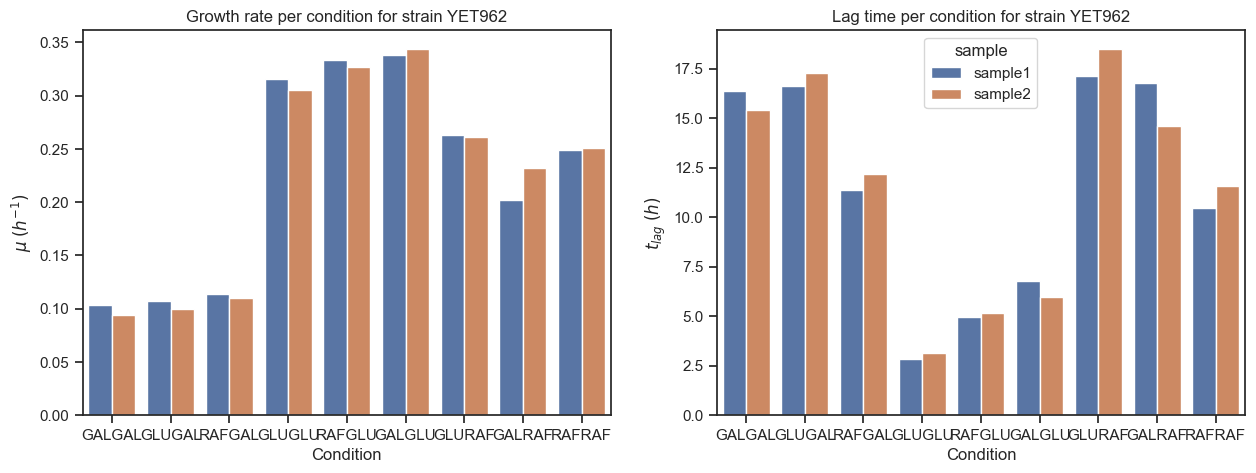

,max_growth_rate_index,start_index,end_index,ws,mu,tlag,tzero,c,column,condition,sample
2,191,153,229,38,0.103262,16.358792,-2.467174,-4.157096,GALGAL_log_sample1,GALGAL,sample1
3,194,153,235,41,0.094366,15.389318,-2.489936,-3.942744,GALGAL_log_sample2,GALGAL,sample2
6,179,144,214,35,0.107304,16.605094,-2.378875,-4.161386,GLUGAL_log_sample1,GLUGAL,sample1
7,197,160,234,37,0.100021,17.280425,-2.336007,-4.065110,GLUGAL_log_sample2,GLUGAL,sample2
10,152,118,186,34,0.113758,11.391924,-2.443428,-3.739874,RAFGAL_log_sample1,RAFGAL,sample1
11,153,119,187,34,0.110091,12.205319,-2.466544,-3.810773,RAFGAL_log_sample2,RAFGAL,sample2
0,44,31,57,13,0.315480,2.849742,-2.383210,-3.282606,GLUGLU_log_sample1,GLUGLU,sample1
1,49,36,62,13,0.305070,3.135921,-2.423679,-3.380737,GLUGLU_log_sample2,GLUGLU,sample2
15,64,52,76,12,0.327354,5.148164,-2.509055,-4.194999,RAFGLU_log_sample2,RAFGLU,sample2
14,60,48,72,12,0.333325,4.937937,-2.505126,-4.151724,RAFGLU_log_sample1,RAFGLU,sample1


<Figure size 640x480 with 0 Axes>

In [450]:
sns.set_style("ticks")

df = final_results.copy()

df["condition"] = df["column"].str.split("_").str[0]
df["sample"] = df["column"].str.split("_").str[2]
df['sort_key']=df["condition"].str[3:]
df=df.sort_values('sort_key').drop(columns="sort_key")

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

sns.barplot(data=df, x="condition", y="mu", hue='sample', ax=ax1)
ax1.set_title(f"Growth rate per condition for strain {strain}")
ax1.set_ylabel("$\mu$ $(h^{-1})$")
ax1.set_xlabel("Condition")
sns.barplot(data=df, x="condition", y="tlag", hue='sample', ax=ax2)
ax2.set_title(f"Lag time per condition for strain {strain}")
ax2.set_ylabel("$t_{lag}$ $(h)$")
ax2.set_xlabel("Condition")
ax1.legend_.remove()
plt.show()
plt.tight_layout()

df

- Did you note that you so far only extracted the growth rates and lagphases of a single strain? Complete the same extraction for the other strains as well and make sure to compare the extracted data for all strains and transitions as well. Again it is your turn to code.

/opt/miniconda3/envs/quant/lib/python3.9/site-packages/seaborn/relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


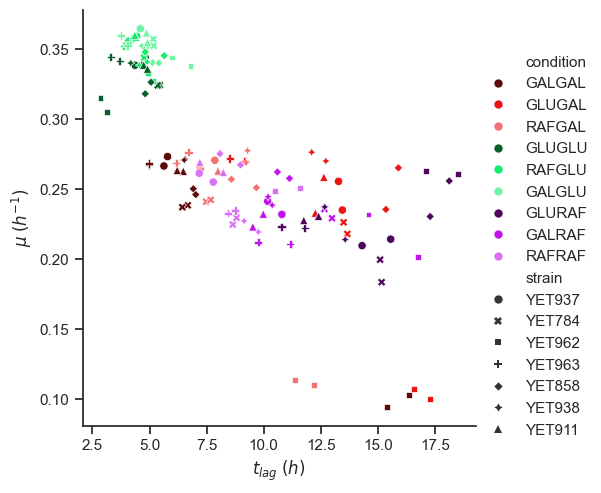

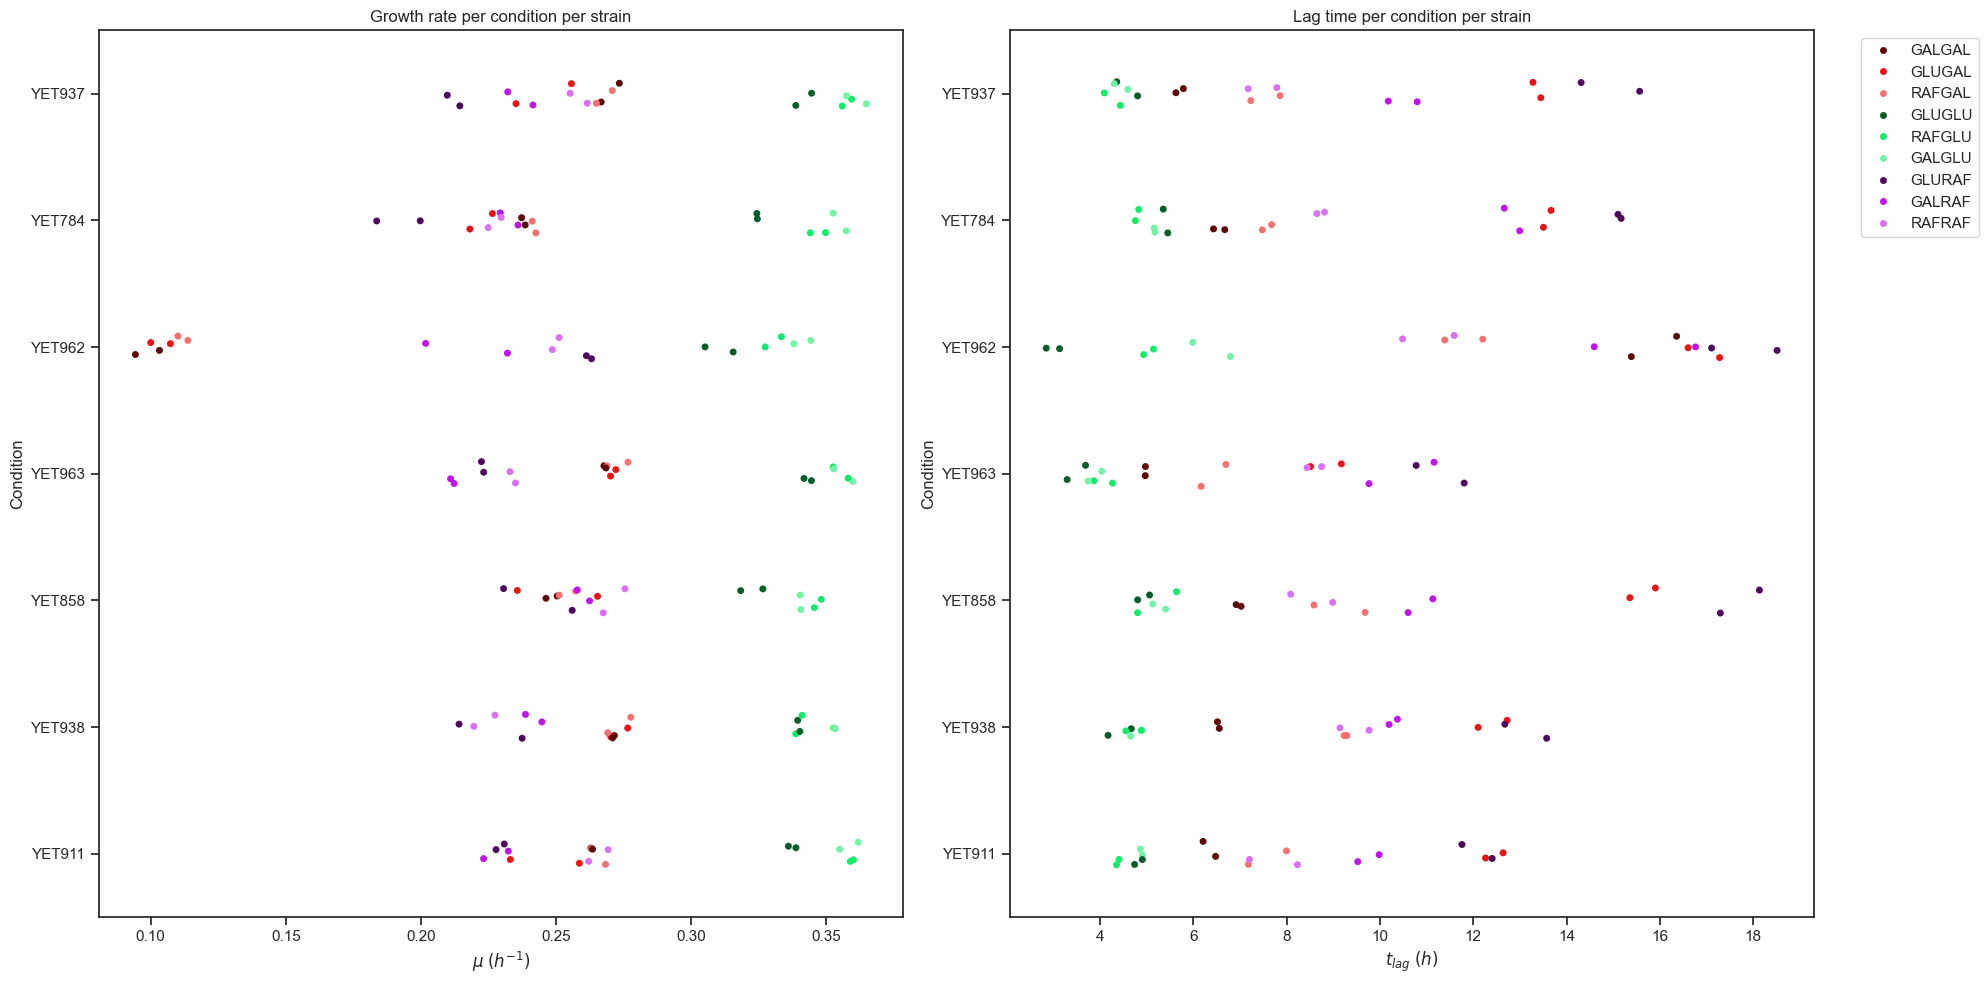

,strain,condition,sample,mu,tlag
0,YET937,GALGAL,sample1,0.266652,5.629733
1,YET937,GLUGAL,sample1,0.255668,13.281249
2,YET937,RAFGAL,sample1,0.264885,7.234418
3,YET937,GALGAL,sample2,0.273375,5.789053
4,YET937,GLUGAL,sample2,0.235157,13.448983
...,...,...,...,...,...
121,YET911,GALRAF,sample1,0.232310,9.984098
122,YET911,RAFRAF,sample1,0.262042,8.233717
123,YET911,RAFRAF,sample2,0.269240,7.204033
124,YET911,GLURAF,sample2,0.227759,11.759499


In [507]:
# your plotting code here
# Repeat the notebook for all other files and save the CSVs. then use the hue and style variables in seaborn to plot all data.
# Make multiple plots and see which ones work best to summarise the data

#Create colour palette for clear visual
import colorsys
base_hues = [
    0.00,  # red
    0.40,  # green
    0.80   # purple
]

luminances = [0.2, 0.5, 0.7]  # dark → light

palette = []

for h in base_hues:
    for l in luminances:
        r, g, b = colorsys.hls_to_rgb(h, l, 0.85)
        palette.append((r, g, b))

result_files = glob("Results/*.csv")
result_files

result_dfs={file.split("/")[1].split("_")[2].split('.')[0]: pd.read_csv(file).drop(columns='Unnamed: 0') for file in result_files}

all_results=[]


for strain_name, result in result_dfs.items():
    df=result.copy()
    df["strain"]=strain_name
    df["sample"]=df["condition"] = df["column"].str.split("_").str[0]
    df["sample"] = df["column"].str.split("_").str[2]
    df["sort_key"] = df["column"].str[3:]
    df = df.sort_values("sort_key").drop(columns="sort_key")
    all_results.append(
        df[["strain", "condition", "sample", "mu", "tlag"]]
    )
long_format_df=pd.concat(all_results,ignore_index=True)



sns.relplot(data=long_format_df,x="tlag",y="mu",hue='condition',style='strain',ax=ax,palette=palette)
plt.xlabel("$t_{lag}$ $(h)$")
plt.ylabel("$\mu$ $(h^{-1})$")

fig,(ax1,ax2)=plt.subplots(ncols=2, figsize=(20,10))
sns.stripplot(data=long_format_df, x="mu",y="strain",hue='condition',ax=ax1,palette=palette)
ax1.set_title(f"Growth rate per condition per strain")
ax1.set_xlabel("$\mu$ $(h^{-1})$")
ax1.set_ylabel("Condition")
sns.stripplot(data=long_format_df, x="tlag",y="strain",hue='condition',ax=ax2,palette=palette)
ax2.set_title(f"Lag time per condition per strain")
ax2.set_xlabel("$t_{lag}$ $(h)$")
ax2.set_ylabel("Condition")
ax1.legend_.remove()   # keep only ax1 legend

ax2.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()
long_format_df



In [1]:
wt_diff=[]
for strain_name, result in result_dfs.items():
    df=result.copy()
    df["strain"]=strain_name
    df["sample"]=df["condition"] = df["column"].str.split("_").str[0]
    df["sample"] = df["column"].str.split("_").str[2]
    df['delta_mu'] = df['mu']-result_dfs['YET858']['mu']
    df['delta_tlag'] = df['tlag']-result_dfs['YET858']['tlag']
    df["sort_key"] = df["column"].str[3:6]
    wt_diff.append(
        df[["strain", "condition", "sample", "delta_mu", "delta_tlag",'sort_key']]
    )
    
wt_df=pd.concat(wt_diff,ignore_index=True)
wt_df=wt_df[wt_df['strain']!="YET858"]
wt_df = wt_df.sort_values("sort_key").drop(columns="sort_key")

fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(20,10))

sns.barplot(data=wt_df, x="strain", y="delta_mu", hue="condition", palette=palette,ax=ax1,errorbar= None)


labels = ax1.get_xticks()

for x in labels[:-1]:
    ax1.axvline(x + 0.5, color="black", lw=0.5, alpha=0.3)
ax1.legend_.remove()

sns.barplot(data=wt_df, x="strain", y="delta_tlag", hue="condition", palette=palette,ax=ax2,errorbar= None)


labels = ax2.get_xticks()

for x in labels[:-1]:
    ax2.axvline(x + 0.5, color="black", lw=0.5, alpha=0.3)
ax2.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
ax1.set_title(f"Difference in growth rate per condition per strain")
ax1.set_ylabel("$\delta \mu$ $(h^{-1})$")
ax1.set_xlabel("Strain")

ax2.set_title(f"Difference in lag time per condition per strain")
ax2.set_ylabel("$\delta t_{lag}$ $(h)$")
ax2.set_xlabel("Strain")
fig.suptitle("Deviation of growth rate and lag time from WT strain",size=20)
fig.tight_layout
fig.show()

NameError: name 'result_dfs' is not defined

Practical done! Make sure to save the figures you created for your report.